In [4]:
import numpy as np


def read_latency_data(file, ignore):
    data = {"end_to_end": [], "service": [], "slos": []}
    with open(file, "r") as file:
        for line in file.readlines():
            span, slo, latency = line.strip().split(",")
            assert span in data.keys()
            data[span].append(int(latency))
            if span == "end_to_end":
                data["slos"].append(int(slo))
    for key in data.keys():
        n_ignore = int(len(data[key]) * ignore)
        data[key] = data[key][n_ignore:]
    return data


def get_pctl(data, pctl):
    data = np.sort(data)
    tail = np.percentile(data, pctl).astype(int)
    return tail


def get_slo_vio(data, slo):
    cnt = 0
    for i in range(len(data)):
        if data[i] > slo[i]:
            cnt += 1
    return cnt / len(data) * 100


def get_slo_vio_select(data, slos, select):
    cnt = 0
    for i in range(len(data)):
        if slos[i] != select:
            continue
        if data[i] > slos[i]:
            cnt += 1
    return cnt / len(data) * 100

In [5]:
rps_values = list(range(100, 2001, 100))
e2e_data = {
    "rps": [],
    "fcfs": [],
    # "fcfs_first": [],
    # "fcfs_second": [],
    "masa": [],
    # "masa_first": [],
    # "masa_second": [],
}

slo1 = int(1e5)
slo2 = slo1 * 2

for rps in rps_values:
    e2e_data["rps"].append(rps)

    file = f"../slo-1e5-1x-fcfs/r{rps}-fcfs.csv"
    data = read_latency_data(file, ignore=0.01)
    e2e_data["fcfs"].append(get_slo_vio(data["end_to_end"], data["slos"]))
    # e2e_data["fcfs_first"].append(get_slo_vio_select(data["end_to_end"], data["slos"], slo1))
    # e2e_data["fcfs_second"].append(get_slo_vio_select(data["end_to_end"], data["slos"], slo2))

    file = f"r{rps}-masa.csv"
    data = read_latency_data(file, ignore=0.01)
    e2e_data["masa"].append(get_slo_vio(data["end_to_end"], data["slos"]))
    # e2e_data["masa_first"].append(get_slo_vio_select(data["end_to_end"], data["slos"], slo1))
    # e2e_data["masa_second"].append(get_slo_vio_select(data["end_to_end"], data["slos"], slo2))

print(e2e_data)
print()

{'rps': [100, 200, 300, 400, 500, 600, 700, 800, 900, 1000, 1100, 1200, 1300, 1400, 1500, 1600, 1700, 1800, 1900, 2000], 'fcfs': [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.002519748529096796, 0.008233625377530437, 0.03004026745963972, 0.16472752722282838, 0.6365140341530438, 2.1990038921798796, 7.042084091193425, 20.976114903644202, 46.850728678001424, 77.43123300261261, 96.38560994590135, 99.96806528874302, 99.99930127709081], 'masa': [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0002405905053362974, 0.0, 0.0, 0.00019807628313816216, 0.0031877888933684617, 26.157189745409386, 92.4862580092561]}



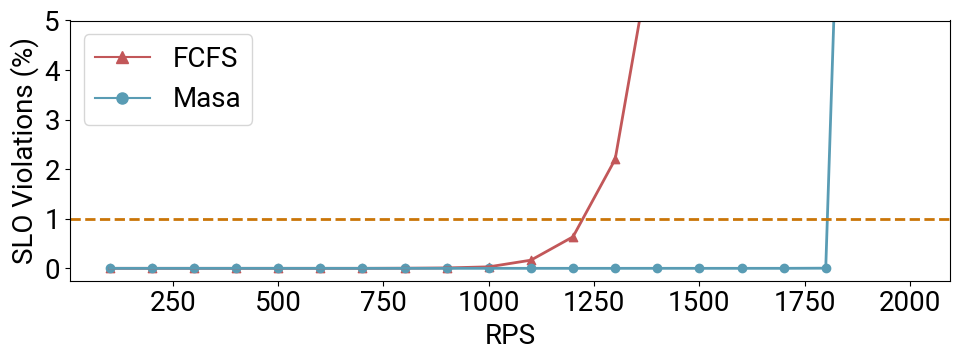

slo: 1, FCFS: 1223, Masa: 1804, Goodput: 148%, Provision: 68%
slo: 5, FCFS: 1358, Masa: 1819, Goodput: 134%, Provision: 75%
slo: 10, FCFS: 1421, Masa: 1838, Goodput: 129%, Provision: 77%


In [7]:
import numpy as np
import matplotlib.pyplot as plt


plt.rcParams["font.family"] = "Roboto"

plt.rcParams.update(
    {
        "font.size": 20,
        "axes.labelsize": 20,
        "axes.titlesize": 20,
        "xtick.labelsize": 20,
        "ytick.labelsize": 20,
        "legend.fontsize": 20,
    }
)

data = e2e_data

x = np.array(data["rps"])
y1 = np.array(data["fcfs"])
y2 = np.array(data["masa"])

plt.figure(figsize=(10, 4))

plt.scatter(
    x,
    y1,
    color="#C25759",
    label="FCFS",
    marker="^",
)
plt.plot(
    x,
    y1,
    label="FCFS",
    color="#C25759",
    linewidth=2,
)

plt.scatter(
    x,
    y2,
    label="Masa",
    color="#599CB4",
    marker="o",
)
plt.plot(
    x,
    y2,
    label="Masa",
    color="#599CB4",
    linewidth=2,
)

# draw a horizontal line representing the SLO 1%
plt.axhline(
    y=1,
    color="#CA7508",
    linestyle="--",
    linewidth=2,
    # label="SLO 1%",
)

# plt.title("SLO Violations")
plt.xlabel("RPS")
# plt.xticks(list(range(200, 2001, 200)))
plt.ylabel("SLO Violations (%)")
plt.ylim(-0.25, 5)
plt.yticks(list(range(0, 6, 1)))

elements = [
    plt.Line2D([0], [0], marker="^", color="#C25759", label="FCFS", markersize=8),
    plt.Line2D([0], [0], marker="o", color="#599CB4", label="Masa", markersize=8),
]
plt.tight_layout()
plt.legend(handles=elements, loc="upper left")
plt.savefig("slo_1e5_8x.pdf")
plt.show()


def solve(x, y, slo):
    # Ensure the input lists are of equal length and are not empty
    if len(x) != len(y) or len(x) == 0:
        return None

    # Traverse the list to find the point where y crosses below slo
    for i in range(1, len(y)):
        if y[i - 1] <= slo and y[i] > slo:
            # Linear interpolation
            # Equation of line (y - y1) = ((y2 - y1) / (x2 - x1)) * (x - x1)
            # Solving for x when y = slo:
            # x = x1 + ((slo - y1) / (y2 - y1)) * (x2 - x1)
            if y[i] != y[i - 1]:  # to avoid division by zero
                x_interpolated = x[i - 1] + ((slo - y[i - 1]) / (y[i] - y[i - 1])) * (
                    x[i] - x[i - 1]
                )
                return x_interpolated

    # If no crossing is found or all y-values are below slo
    return None


for slos in [1, 5, 10]:
    x1 = round(solve(x, y1, slos))
    x2 = round(solve(x, y2, slos))
    goodput = x2 / x1 * 100
    provision = x1 / x2 * 100
    print(f"slo: {slos}, FCFS: {x1}, Masa: {x2}, Goodput: {round(goodput)}%, Provision: {round(provision)}%")